## XY - Plane mapping density probability distribution function $P(X)$

#### Method 1: hypercube integration

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
sys.path.append(str(Path().resolve().parent))
import multimin as mm
import time
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    trasformation_X_to_E,
    compute_jacobian_XoE,
    Jacobian_qei_to_QEI,
    P_E_CMND
    )

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


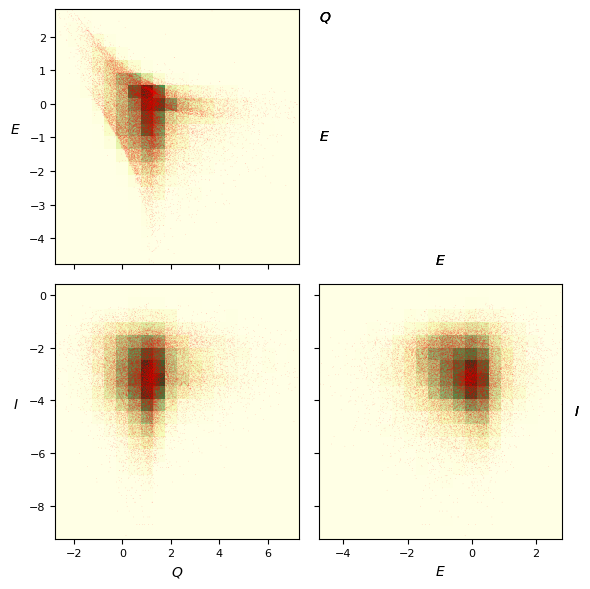

In [3]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [4]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()
    
    #not_sense_orbit = 0
    for idx in range(x_flat.size):
        #print('evaluating state vector: ', x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        #print('Orbital elements ', q, e, i, Omega, w, M, a)
        if q > 1.35 or e >= 1: 
            #print("--------------NO SENSE ORBIT-----------------")
            #print('evaluating state vector: ', x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
            #print('Orbital elements ', q, e, i, Omega, w, M, a)
            #not_sense_orbit += 1
            P.flat[idx] = 0
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
                if det == 0 or not np.isfinite(det):
                    #print("------------PROBLEMATIC POINT------------")
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)

                    #if np.isnan(P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)):
                        #print('--------------Nan value encounter-----------')
                        #print(P_E_CMND(q, e, i, F), abs(inv_det), abs(det_QEI))
                    
    return P.reshape(shape)

def  surface_integral_P_X_CMND(center, widths, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the surface integral of P_xyvxvy in a hypercube centered at (x, y, vx, vy)
    with dimensions (dx, dy, dvx, dvy) using Gauss-Legendre quadrature.

    Parameters:
        center: tuple/list/array of (x, y, vx, vy) center
        widths: tuple/list/array of (dx, dy, dvx, dvy) side lengths
        max_elemetns: tuple/list/array of (a_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    x0, y0, z0, vx0, vy0, vz0 = center
    dx, dy, dz, dvx, dvy, dvz = widths
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for each dimension
    x_pts = x0 + 0.5*dx*pts
    y_pts = y0 + 0.5*dy*pts
    z_pts = z0 + 0.5*dz*pts
    vx_pts = vx0 + 0.5*dvx*pts
    vy_pts = vy0 + 0.5*dvy*pts
    vz_pts = vz0 + 0.5*dvz*pts

    # Create meshgrid of all quadrature points
    X, Y, Z, VX, VY, VZ = np.meshgrid(x_pts, y_pts, z_pts, vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ, WVX, WVY, WVZ = np.meshgrid(wts, wts, wts, wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    Xf = X.ravel()
    Yf = Y.ravel()
    Zf = Z.ravel()
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ * WVX * WVY * WVZ).ravel()
    # Evaluate P at all points
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor
    integral = np.sum(Pf * WF) * (0.5*dx) * (0.5*dy) * (0.5*dz) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    #return integral, y_points
    return integral

In [26]:
x = 1.0
y = 0.4
z = 0.0
vx = 0.01
vy = 1.0
vz = 0.01
q_max = 1.35
e_max = 1.0
i_max = np.pi
P_X_CMND(x, y, z, vx, vy, vz, q_max, e_max, i_max, mu, F)

array(1.39653615e-07)

### Integrating in the XY - Plane grid mapping in a hypercube 

In [8]:
xmin, xmax = 0, 2
ymin, ymax = -2, 0
dx_grid = 0.1
dy_grid = 0.1

x_vals = np.arange(xmin, xmax + dx_grid, dx_grid)
y_vals = np.arange(ymin, ymax + dy_grid, dy_grid)

NX = len(x_vals)
NY = len(y_vals)

# Storage array for results
integral = np.zeros((NX, NY))

dtype = [
    ("value", float),
    ("x", float),
    ("y", float)
]

probability_map = np.zeros((NX, NY), dtype=dtype)

fixed_z  = 0.0
fixed_vx = 0.0
fixed_vz = 0.0

dx = 0.1     # width in x
dy = 0.1     # width in y
dz = 0.1
dvx = 1000 * (1/AU_m) * year
dvy = 1000 * (1/AU_m) * year
dvz = 1000 * (1/AU_m) * year

widths = (dx, dy, dz, dvx, dvy, dvz)

a = 1.0
vc = (mu/a)**0.5

max_elements = (1.35, 1.0, np.pi) 

for ix, xv in enumerate(x_vals):
    for iy, yv in enumerate(y_vals):
        center = (xv, yv, fixed_z, fixed_vx, vc, fixed_vz)
        print("evaluating at", center)

        try:
            val = surface_integral_P_X_CMND(
                center=center,
                widths=widths,
                max_elements=max_elements,
                n_points=6,    
                mu=mu,
                F=F           
            )
        except Exception as err:
            print("Runtime error at center =", center)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            val = np.nan

        probability_map[ix, iy] = (val, xv, yv)
        print(ix, iy, val)

print("Mapping complete!")
np.save(f"data_results/method 1/PX_integration_XY_grid_xmin={xmin}_xmax={xmax}_ymin={ymin}_ymax={ymax}3.npy", probability_map)

evaluating at (0.0, -2.0, 0.0, 0.0, 6.2840227308020005, 0.0)
Runtime error at center = (0.0, -2.0, 0.0, 0.0, 6.2840227308020005, 0.0)
   → Setting integral to NaN.
0 0 nan
evaluating at (0.0, -1.9, 0.0, 0.0, 6.2840227308020005, 0.0)
Runtime error at center = (0.0, -1.9, 0.0, 0.0, 6.2840227308020005, 0.0)
   → Setting integral to NaN.
0 1 nan
evaluating at (0.0, -1.7999999999999998, 0.0, 0.0, 6.2840227308020005, 0.0)
0 2 5.220121047527694e-25
evaluating at (0.0, -1.6999999999999997, 0.0, 0.0, 6.2840227308020005, 0.0)
0 3 9.178350757811065e-24
evaluating at (0.0, -1.5999999999999996, 0.0, 0.0, 6.2840227308020005, 0.0)
0 4 6.872827258661548e-23
evaluating at (0.0, -1.4999999999999996, 0.0, 0.0, 6.2840227308020005, 0.0)
0 5 3.002175034235562e-22
evaluating at (0.0, -1.3999999999999995, 0.0, 0.0, 6.2840227308020005, 0.0)
0 6 9.159414273847983e-22
evaluating at (0.0, -1.2999999999999994, 0.0, 0.0, 6.2840227308020005, 0.0)
0 7 2.2131362962662046e-21
evaluating at (0.0, -1.1999999999999993, 0.

C:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\utils\Utils.py:783: RuntimeWarning: divide by zero encountered in scalar divide
  a = q/(1-e)


0 12 1.4092486769291993e-19
evaluating at (0.0, -0.6999999999999988, 0.0, 0.0, 6.2840227308020005, 0.0)
0 13 1.338369958420256e-19
evaluating at (0.0, -0.5999999999999988, 0.0, 0.0, 6.2840227308020005, 0.0)
0 14 4.322809141853733e-20
evaluating at (0.0, -0.49999999999999867, 0.0, 0.0, 6.2840227308020005, 0.0)
0 15 2.0517082447198176e-20
evaluating at (0.0, -0.3999999999999986, 0.0, 0.0, 6.2840227308020005, 0.0)
0 16 1.370062512497685e-20
evaluating at (0.0, -0.2999999999999985, 0.0, 0.0, 6.2840227308020005, 0.0)
0 17 7.673741396201022e-21
evaluating at (0.0, -0.1999999999999984, 0.0, 0.0, 6.2840227308020005, 0.0)
0 18 2.6017299223774194e-21
evaluating at (0.0, -0.09999999999999831, 0.0, 0.0, 6.2840227308020005, 0.0)
0 19 3.0129158433641797e-22
evaluating at (0.0, 1.7763568394002505e-15, 0.0, 0.0, 6.2840227308020005, 0.0)
0 20 1.5465491221035887e-22
evaluating at (0.1, -2.0, 0.0, 0.0, 6.2840227308020005, 0.0)
Runtime error at center = (0.1, -2.0, 0.0, 0.0, 6.2840227308020005, 0.0)
   → 

<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_21792\1704779026.py:24: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


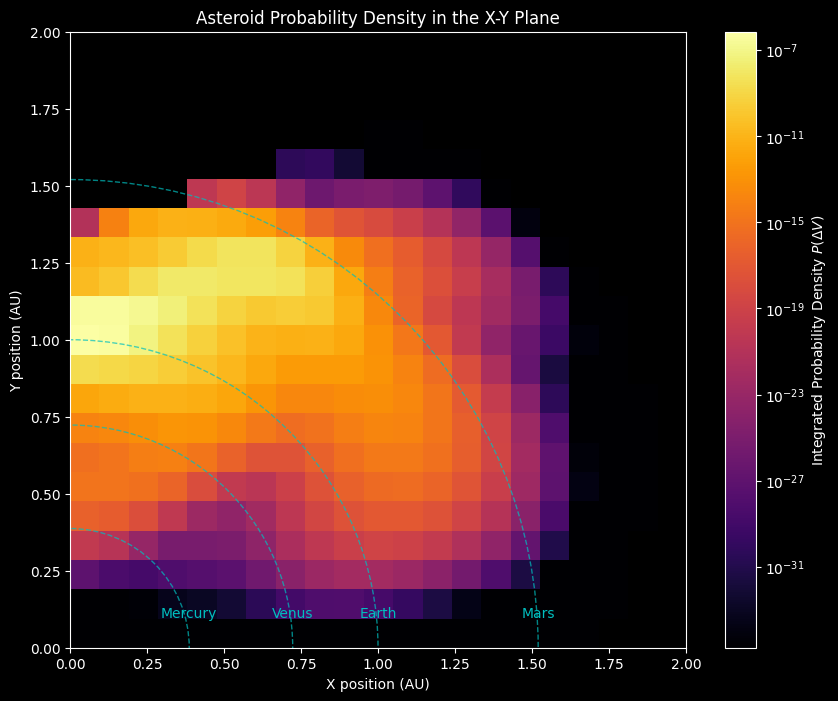

In [7]:
with open("data_results/method 1/PX_integration_XY_grid_xmin=0_xmax=2_ymin=0_ymax=23.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = 0, 2
y_min, y_max = 0, 2

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

# Use imshow to create the heatmap. `origin='lower'` puts (x_min, y_min) at the bottom-left.
# `extent` correctly labels the axes with your AU values.
im = ax.imshow(
    integral_grid['value'], 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

# Add a colorbar to show the scale
cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')
#cbar.set_label('Log10 of Integrated Probability Density') # Use if plotting log

# Add labels and title
ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') # Ensure x and y axes have the same scale

# Add orbits of planets for context
def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_22844\3110054844.py:24: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


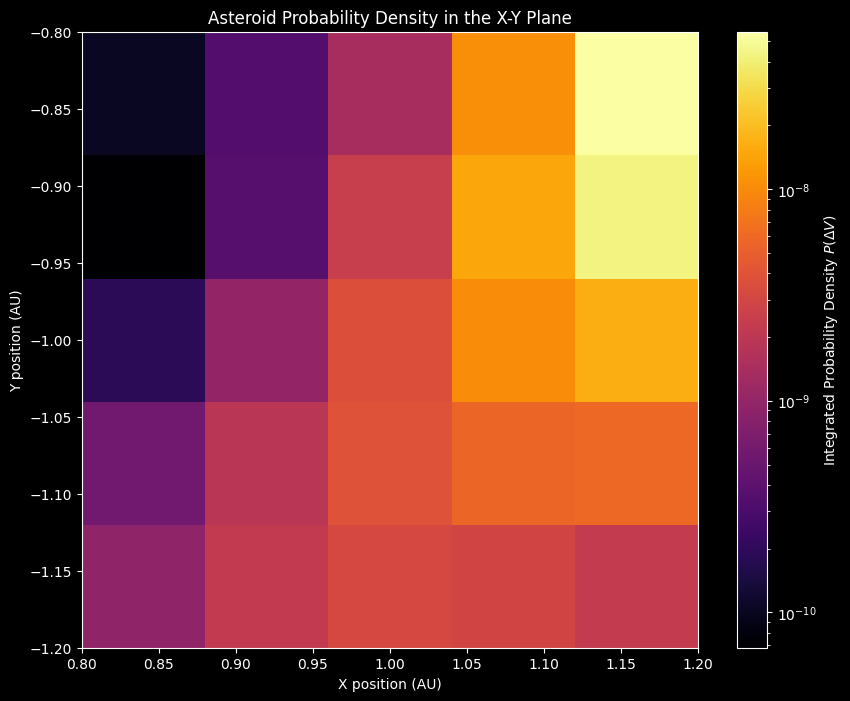

In [69]:
with open("data_results/method 1/PX_integration_XY_grid_xmin=0.8_xmax=1.2_ymin=-1.2_ymax=-0.8.npy", "rb") as f:
    integral_grid2 = np.load(f, allow_pickle=False)

x_min, x_max = 0.8, 1.2
y_min, y_max = -1.2, -0.8


plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
# Use imshow to create the heatmap. `origin='lower'` puts (x_min, y_min) at the bottom-left.
# `extent` correctly labels the axes with your AU values.
im = ax.imshow(
    integral_grid2['value'], 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

# Add a colorbar to show the scale
cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')
#cbar.set_label('Log10 of Integrated Probability Density') # Use if plotting log

# Add labels and title
ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') # Ensure x and y axes have the same scale

# Add orbits of planets for context
def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

#plot_orbit(0.387, 'Mercury')
#plot_orbit(0.723, 'Venus')
#plot_orbit(1.0, 'Earth')
#plot_orbit(1.52, 'Mars')

plt.show()

In [5]:
fixed_z  = 0.0
fixed_vx = 0.0
fixed_vz = 0.0

dx = 0.1     # width in x
dy = 0.1     # width in y
dz = 0.1
dvx = 1000 * (1/AU_m) * year
dvy = 1000 * (1/AU_m) * year
dvz = 1000 * (1/AU_m) * year

widths = (dx, dy, dz, dvx, dvy, dvz)

max_elements = (1.35, 1.0, np.pi) 


xv = 1.0
yv = -1.0
#a = (xv**2 + yv**2)**0.5
vc = (mu/1.0)**0.5
center = (xv, yv, fixed_z, fixed_vx, vc, fixed_vz)

val_first_quadrant_mars = surface_integral_P_X_CMND(
    center=center,
    widths=widths,
    max_elements=max_elements,
    n_points=6,    
    mu=mu,
    F=F           
)
val_first_quadrant_mars, np.log10(val_first_quadrant_mars)

(3.6848076199617255e-09, -8.433585181283908)

In [ ]:
(3.6848076199617664e-09, -8.433585181283902)

In [6]:
center, widths, max_elements, mu, 

((1.0, -1.0, 0.0, 0.0, 6.2840227308020005, 0.0),
 (0.1,
  0.1,
  0.1,
  0.21094652406417114,
  0.21094652406417114,
  0.21094652406417114),
 (1.35, 1.0, 3.141592653589793),
 39.48894168123623)

In [55]:
xv = -1.5
yv = 1.5
#a = (xv**2 + yv**2)**0.5
vc = (mu/1.5)**0.5
center = (xv, yv, fixed_z, fixed_vx, -vc, fixed_vz)

val_second_quadrant_mars = surface_integral_P_X_CMND(
    center=center,
    widths=widths,
    max_elements=max_elements,
    n_points=8,    
    mu=mu,
    F=F           
)
val_second_quadrant_mars, np.log10(val_second_quadrant_mars)

(2.036285945076893e-09, -8.691161236330696)

In [50]:
xv = -1.5
yv = -1.5
#a = (xv**2 + yv**2)**0.5
vc = (mu/1.5)**0.5
center = (xv, yv, fixed_z, fixed_vx, -vc, fixed_vz)

val_third_quadrant_mars = surface_integral_P_X_CMND(
    center=center,
    widths=widths,
    max_elements=max_elements,
    n_points=8,    
    mu=mu,
    F=F           
)
val_third_quadrant_mars, np.log10(val_third_quadrant_mars)

(2.0362859450768904e-09, -8.691161236330696)

In [56]:
xv = 1.5
yv = -1.5
#a = (xv**2 + yv**2)**0.5
vc = (mu/1.5)**0.5
center = (xv, yv, fixed_z, fixed_vx, vc, fixed_vz)

val_fourth_quadrant_mars = surface_integral_P_X_CMND(
    center=center,
    widths=widths,
    max_elements=max_elements,
    n_points=8,    
    mu=mu,
    F=F           
)
val_fourth_quadrant_mars, np.log10(val_fourth_quadrant_mars)

(2.036285945076889e-09, -8.691161236330696)

In [52]:
fixed_z  = 0.0
fixed_vx = 0.0
fixed_vz = 0.0

dx = 0.1     # width in x
dy = 0.1     # width in y
dz = 0.1
dvx = 1000 * (1/AU_m) * year
dvy = 1000 * (1/AU_m) * year
dvz = 1000 * (1/AU_m) * year

widths = (dx, dy, dz, dvx, dvy, dvz)

max_elements = (1.35, 1.0, np.pi) 


xv = 1.0
yv = 1.0
#a = (xv**2 + yv**2)**0.5
vc = (mu/1)**0.5
center = (xv, yv, fixed_z, fixed_vx, vc, fixed_vz)

center, widths, max_elements, mu

val_earth = surface_integral_P_X_CMND(
    center=center,
    widths=widths,
    max_elements=max_elements,
    n_points=8,    
    mu=mu,
    F=F           
)
val_earth, np.log10(val_earth)

(3.6991153284255238e-09, -8.431902128344507)

### Integrating in the XY - Plane grid mapping in a cube in ($x$,$y$,$z$) and in a sphere in ($v_x$, $v_y$, $v_z$)

In [6]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.Utils import (
    trasformation_X_to_E, 
    compute_jacobian_XoE,
    Jacobian_qei_to_QEI,
    P_E_CMND
)
from tqdm import tqdm
import numpy as np


In [7]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    neas_number = 0
    not_neas_number = 0

    for idx in range(x_flat.size):
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        if q > 1.35 or e > 1: 
            P.flat[idx] = 0
            neas_number += 1
        else: 
            J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
            J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
            with np.errstate(divide='ignore', invalid='ignore'):
                det = np.linalg.det(J)
                det_QEI = J_qei_to_QEI[0,0] * J_qei_to_QEI[1,1] * J_qei_to_QEI[2,2]
                if det == 0 or not np.isfinite(det):
                    print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)
                    not_neas_number += 1

                    if np.isnan(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_QEI)):
                        print('Nan value encounter: ', P_E_CMND(a, e, i, F), abs(inv_det), abs(det_QEI))
                        print("Problematic point: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
                    
    return P.reshape(shape)

In [ ]:
def sphere_surface_integral_P_X_CMND(
    r: np.array,
    dr: np.array,
    c_v: np.array,
    r_v: float,
    deg: int,
    q_max: int, 
    e_max: int, 
    i_max: int,
    mu=1, 
    F=mm.FitCMND
) -> float:
    """
    Calculates the 6D integral of P_X_CMND using Gauss-Legendre Quadrature.
    Robust to P_X_CMND returning extra diagnostic values.
    """
    from numpy.polynomial.legendre import leggauss
    # 1. Get Gauss-Legendre nodes and weights
    nodes, weights = leggauss(deg)

    # 2. Velocity Mesh (Cartesian Box)
    x_vals = r[0] + dr[0] * nodes
    y_vals = r[1] + dr[1] * nodes
    z_vals = r[2] + dr[2] * nodes
    
    # 3. Position Mesh (Spherical Coordinates)
    # rho: [0, r], theta: [0, pi], phi: [0, 2pi]
    rho_vals = (r_v / 2.0) * (nodes + 1)
    theta_vals = (np.pi / 2.0) * (nodes + 1)
    phi_vals = np.pi * (nodes + 1)

    # 4. Construct the 6D Meshgrid
    # Order: rho, theta, phi, vx, vy, vz
    Rho, Theta, Phi, X, Y, Z = np.meshgrid(
        rho_vals, theta_vals, phi_vals, x_vals, y_vals, z_vals, indexing='ij'
    )
    
    # Mesh the weights
    W_rho, W_theta, W_phi, W_x, W_y, W_z = np.meshgrid(
        weights, weights, weights, weights, weights, weights, indexing='ij'
    )

    # 5. Coordinate Transformations
    sin_theta = np.sin(Theta)
    cos_theta = np.cos(Theta)
    sin_phi = np.sin(Phi)
    cos_phi = np.cos(Phi)
    
    VX = c_v[0] + Rho * sin_theta * cos_phi
    VY = c_v[1] + Rho * sin_theta * sin_phi
    VZ = c_v[2] + Rho * cos_theta

    # 6. Calculate Integration Weights (Jacobians)
    scale_factors = (r_v / 2.0) * (np.pi / 2.0) * np.pi * (dr[0] * dr[1] * dr[2])
    spherical_jacobian = (Rho**2) * sin_theta
    
    total_weights = (
        W_rho * W_theta * W_phi * W_x * W_y * W_z 
        * spherical_jacobian 
        * scale_factors
    )

    # 7. Evaluate Function
    P_output = P_X_CMND(X, Y, Z, VX, VY, VZ, q_max, e_max, i_max, mu, F=F)
        
    P_grid = P_output.reshape(total_weights.shape)
    
    weighted_values = P_grid * total_weights
    
    integral_result = np.sum(weighted_values)
    
    return integral_result

In [9]:
c_x, c_y, c_z = 1.0, 0.0, 0.0
center_pos = np.array([c_x, c_y, c_z])
dr = np.array([0.1, 0.1, 0.5])   

a = (c_x**2 + c_y**2)**0.5

v_x, v_y, v_z = 0.0, (mu/a)**0.5, 0.0
center_vel = np.array([v_x, v_y, v_z])

r_v = (2*mu/a)**0.5

degree = 6 
max_elements = (1.35, 1.0, np.pi) 

result = sphere_surface_integral_P_X_CMND(
    center_pos, dr, 
    center_vel, r_v, 
    degree, 
    q_max=max_elements[0], e_max=max_elements[1], i_max=max_elements[2], mu=mu, F=F
)

In [14]:
result

0.0022380062098957135

In [10]:
x_min, x_max = -0.2, 0.2
y_min, y_max = -1.5, -0.4

z_center = 0.0
dx_cell, dy_cell = 0.1, 0.1
dz = 0.1   

vx_center = 0.01
vy_center = 0.01
vz_center = 0.01

max_elements = (1.35, 1.0, np.pi) 

x_steps = int((x_max - x_min) / dx_cell) + 1
y_steps = int((y_max - y_min) / dy_cell) + 1

x_centers = np.linspace(x_min, x_max, x_steps)
y_centers = np.linspace(y_min, y_max, y_steps)

degree = 6

probability_map = np.zeros((len(y_centers), len(x_centers)))
grid_map = []

print("Starting probability mapping...")
for i, y_c in enumerate(tqdm(y_centers, desc="Y-axis progress")):
    for j, x_c in enumerate(x_centers):
        corners = np.array([[x_c - dx_cell, y_c - dy_cell],
                    [x_c + dx_cell, y_c - dy_cell],
                    [x_c - dx_cell, y_c + dy_cell],
                    [x_c + dx_cell, y_c + dy_cell]])

        a_s = np.zeros_like(corners)
        for idx, corner in enumerate(corners):
            a_s[idx] = (corner[0]**2 + corner[1]**2)**0.5                 

        a_s = a_s[:,0]
        Rvs = (2*mu/a_s)**0.5
        r_v = np.min(Rvs)

        center_pos = np.array([x_c, y_c, z_center])
        dr = np.array([dx_cell, dy_cell, dz])
        
        center_vel = np.array([vx_center, vy_center, vz_center])
        print(center_pos, dr, center_vel, r_v)
        try:
        # Calculate the integral for this hypervolume
            prob_value = sphere_surface_integral_P_X_CMND(
                center_pos, dr, 
                center_vel, r_v, 
                degree, 
                q_max=max_elements[0], e_max=max_elements[1], i_max=max_elements[2], 
                mu=mu, 
                F=F
            )
            print(prob_value)
        except Exception as err:
            print("Runtime error at center =", center_pos, center_vel)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = prob_value
        grid_map.append(center_pos)
header = f"P(X) XY plane integration cube position and spheric velocity\nmethod: min Rv value for all corners\n x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}, dx_cell={dx_cell}, dy_cell={dy_cell}, dz={dz}, vx_center={vx_center}, vy_center={vy_center}, vz_center={vz_center}"

# Save to a .dat file
print("Mapping complete!")
np.savetxt(f"PX_integration_XY_grid_xmin={x_min}_xmax={x_max}_ymin={y_min}_ymax={y_max}.dat", probability_map, header=header, delimiter=', ')
np.savetxt(f"XY_grid_map_xmin={x_min}_xmax={x_max}_ymin={y_min}_ymax={y_max}.dat", grid_map, header=header, delimiter=', ')

Starting probability mapping...


Y-axis progress:   0%|          | 0/12 [00:00<?, ?it/s]

[-0.2 -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 6.965323257929109
0.00012184301183794976
[-0.1 -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 6.998571568999538
0.0001197866860346569
[ 0.  -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.018906615930132
0.00012167539063086806
[ 0.1 -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 6.998571568999538
0.00012057281197984564
[ 0.2 -1.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 6.965323257929109


Y-axis progress:   8%|▊         | 1/12 [03:33<39:08, 213.53s/it]

0.00012221088058809562
[-0.2 -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.18536411660128
0.00015130777892736146
[-0.1 -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.224268430124559
0.000163366629966017
[ 0.  -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.248124346707702
0.00016602591695726154
[ 0.1 -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.224268430124559
0.00016339877001684367
[ 0.2 -1.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 7.18536411660128


...

0.0001317830707743291
[-0.2 -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 10.85049663740599
8.490059648899102e-05
[-0.1 -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 11.174748234401761
8.206675230790024e-05
[ 0.  -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 11.394684745227092
8.570969991719156e-05
[ 0.1 -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 11.174748234401761
8.230497118684997e-05
[ 0.2 -0.5  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 10.85049663740599


Y-axis progress:  92%|█████████▏| 11/12 [49:13<04:56, 296.98s/it]

8.534911428161515e-05
[-0.2 -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 11.638124958176945
5.4592363613480886e-05
[-0.1 -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 12.110253820420974
4.6907759594856114e-05
[ 0.  -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 12.445415720835678
4.816706774213573e-05
[ 0.1 -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 12.110253820420974
4.7047061423259835e-05
[ 0.2 -0.4  0. ] [0.1 0.1 0.1] [0.01 0.01 0.01] 11.638124958176945


Y-axis progress: 100%|██████████| 12/12 [55:02<00:00, 275.17s/it]

5.4901275669094805e-05
Mapping complete!


In [31]:
probability_map

array([[0.00080234, 0.00079677],
       [0.0008715 , 0.00076385]])

In [19]:
with open("PX_integration_XY_grid_xmin=-0.2_xmax=0.2_ymin=0.4_ymax=1.5.dat", "rb") as f:
    integral_grid = np.loadtxt(f, delimiter=',', skiprows=3)

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_18804\1729546405.py:22: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


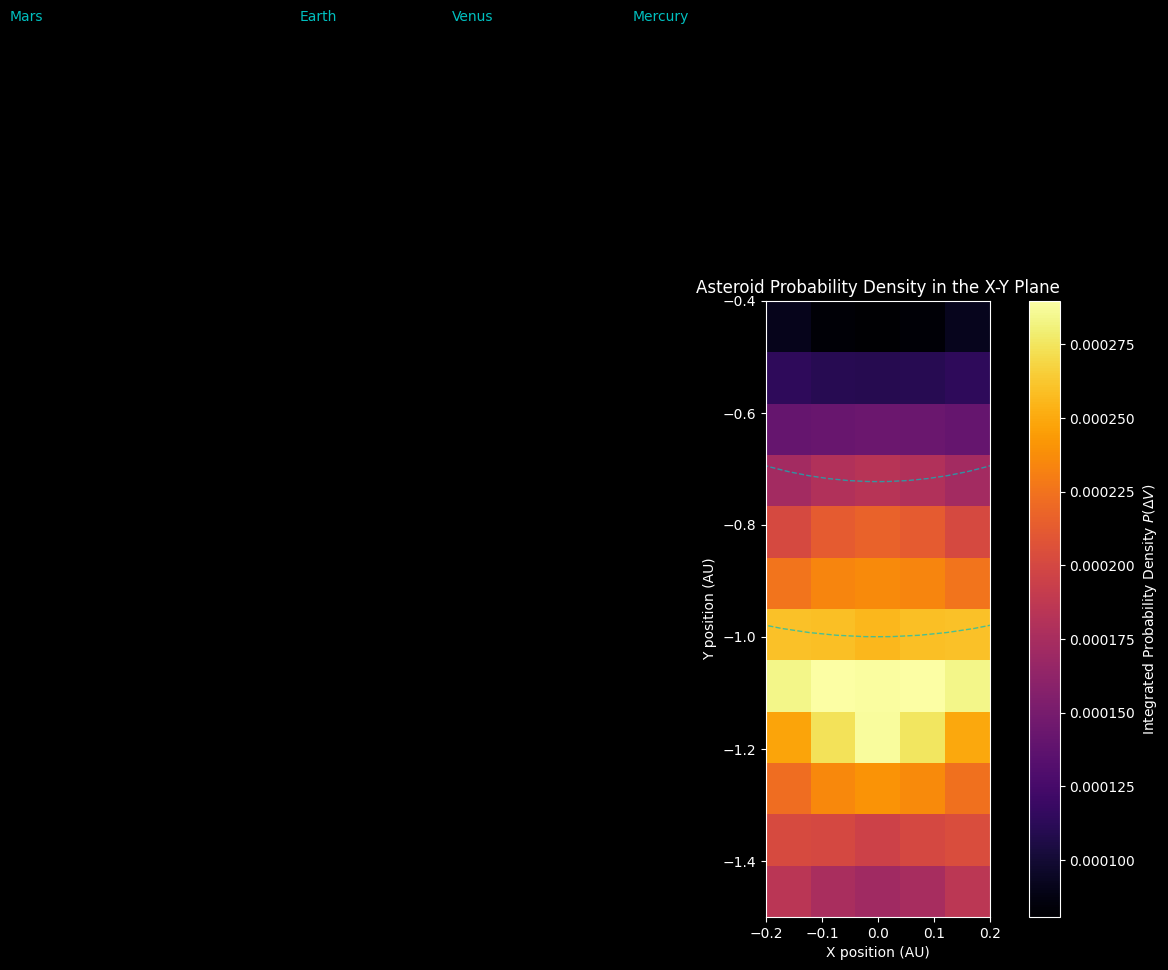

In [31]:
with open("PX_integration_XY_grid_xmin=-0.2_xmax=0.2_ymin=-1.5_ymax=-0.42.dat", "rb") as f:
    integral_grid = np.loadtxt(f, delimiter=',', skiprows=3)
    
x_min, x_max = -0.2, 0.2
y_min, y_max = -1.5, -0.4

log_prob_map = np.log10(integral_grid + 1e-20) 

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest'
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(-0.387, 'Mercury')
plot_orbit(-0.723, 'Venus')
plot_orbit(-1.0, 'Earth')
plot_orbit(-1.52, 'Mars')

plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_18804\2149520875.py:22: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


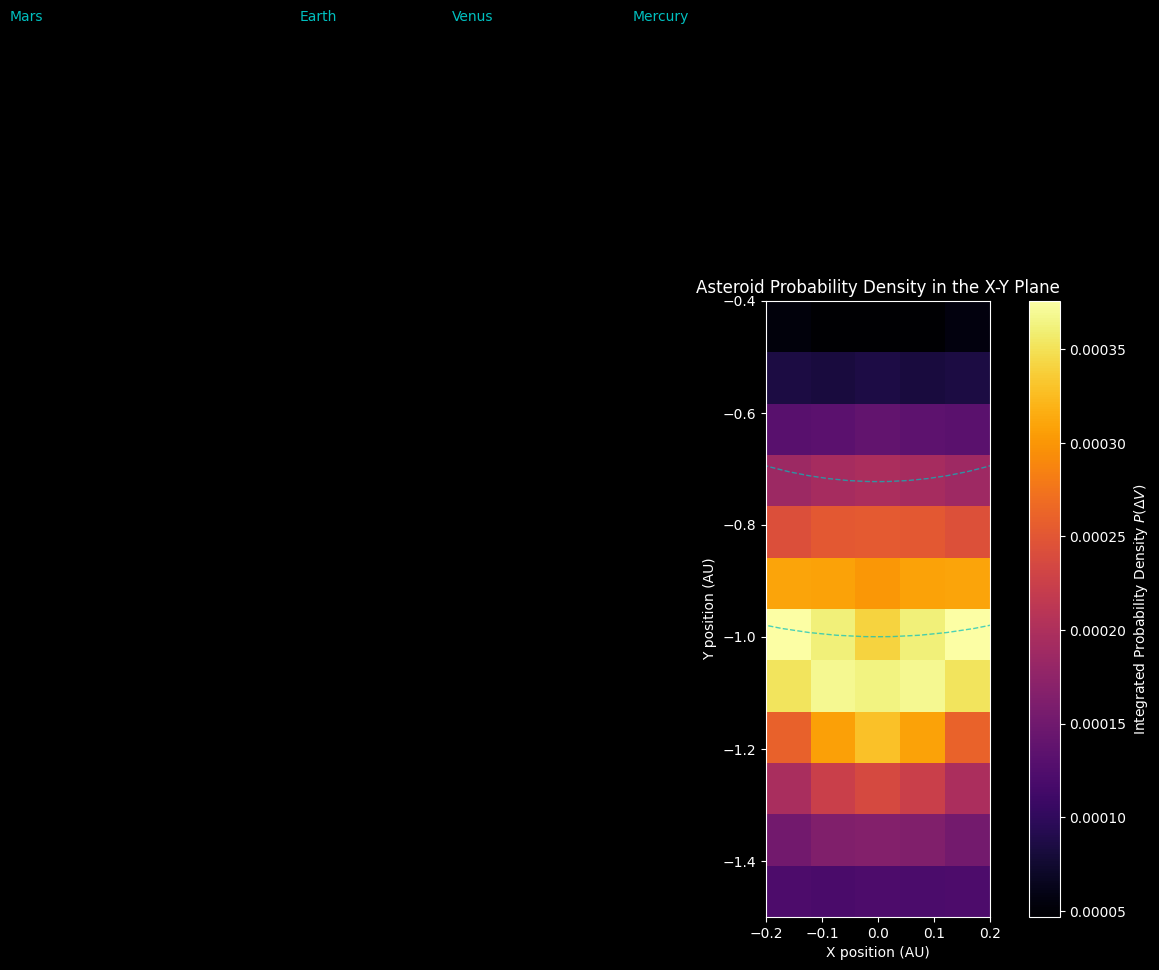

In [12]:
with open("PX_integration_XY_grid_xmin=-0.2_xmax=0.2_ymin=-1.5_ymax=-0.4.dat", "rb") as f:
    integral_grid = np.loadtxt(f, delimiter=',', skiprows=3)
    
x_min, x_max = -0.2, 0.2
y_min, y_max = -1.5, -0.4

log_prob_map = np.log10(integral_grid + 1e-20) 

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest'
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(-0.387, 'Mercury')
plot_orbit(-0.723, 'Venus')
plot_orbit(-1.0, 'Earth')
plot_orbit(-1.52, 'Mars')

plt.show()

In [35]:
6**3

216

In [33]:
2**6

64